# 📦 Import Required Libraries

All necessary libraries for data manipulation, visualization, machine learning, and model persistence are imported here.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_curve, auc
from imblearn.combine import SMOTETomek
from sklearn.metrics import precision_recall_curve
from scipy.stats import norm
import joblib
import warnings
warnings.filterwarnings('ignore')

# 🔍 Data Overview

In this section, we load the dataset and perform an initial inspection to understand its structure, dimensions, missing values, and basic statistics.

In [ ]:
bank_data = pd.read_csv('Churn_Modelling.csv')
bank_data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
print ("the shape of the data is : ",bank_data.shape)

the shape of the data is :  (10000, 14)


In [4]:
bank_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
bank_data.drop(['RowNumber','CustomerId','Surname'],axis=1,inplace=True)

In [6]:
bank_data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
bank_data.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [8]:
print ("Nmber of duplicate data is ",bank_data.duplicated().sum())

Nmber of duplicate data is  0


In [9]:
bank_data.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


# 🛠️ Feature Engineering

This section enriches the dataset by constructing new features derived from existing ones. The goal is to expose hidden patterns that raw features alone may not capture.

## New Feature Categories: Ratios, Interactions & Flags

These engineered features are designed to highlight **non-obvious relationships** between customer attributes.

### 1 — Ratios
| Feature | Formula | Purpose |
|---|---|---|
| `Balance_to_Salary` | Balance / (EstimatedSalary + 1) | Compares savings relative to income |
| `CreditScore_to_Age` | CreditScore / (Age + 1) | Normalizes credit strength by customer age |
| `Age_to_Tenure` | Age / (Tenure + 1) | Measures how long a customer has been with the bank relative to their age |

### 2 — Interaction Terms
| Feature | Formula | Purpose |
|---|---|---|
| `CreditScore_Age` | CreditScore × Age | Captures joint effect of credit score and age on churn |
| `Balance_Age` | Balance × Age | Examines whether older customers with higher balances behave differently |
| `Products_Tenure` | NumOfProducts × Tenure | Reflects customer engagement and loyalty over time |

### 3 — Binary Flags
| Feature | Condition | Purpose |
|---|---|---|
| `High_Balance` | 1 if Balance > EstimatedSalary, else 0 | Flags customers with disproportionately high savings |

> **Overall objective:** capture proportional relationships, model combined feature effects, and create interpretable signals for segmentation and churn prediction.

In [10]:

bank_data['Balance_to_Salary'] = bank_data['Balance'] / (bank_data['EstimatedSalary'] + 1)
bank_data['CreditScore_to_Age'] = bank_data['CreditScore'] / (bank_data['Age'] + 1)
bank_data['Age_to_Tenure'] = bank_data['Age'] / (bank_data['Tenure'] + 1)


bank_data['CreditScore_Age'] = bank_data['CreditScore'] * bank_data['Age']
bank_data['Balance_Age'] = bank_data['Balance'] * bank_data['Age']
bank_data['Products_Tenure'] = bank_data['NumOfProducts'] * bank_data['Tenure']


bank_data['High_Balance'] = (bank_data['Balance'] > bank_data['EstimatedSalary']).astype(int)


bank_data.head()


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Balance_to_Salary,CreditScore_to_Age,Age_to_Tenure,CreditScore_Age,Balance_Age,Products_Tenure,High_Balance
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.000000,14.395349,14.000000,25998,0.00,2,0
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.744670,14.476190,20.500000,24928,3436122.26,1,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1.401362,11.674419,4.666667,21084,6705753.60,24,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.000000,17.475000,19.500000,27261,0.00,2,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1.587035,19.318182,14.333333,36550,5396965.26,2,1


## 📊 Exploratory Data Analysis (EDA)

Three types of visualizations are used to understand the data before modeling:

1. **Class Distribution** — A countplot of the target variable (`Exited`) reveals the imbalance between churned and retained customers, motivating the use of resampling techniques such as SMOTETomek.
2. **Distribution Plots** — Histograms with KDE overlays are drawn for all numeric features to assess normality and guide decisions on scaling or transformation.
3. **Boxplots** — Key numeric variables are examined for outliers, providing a clearer view of each feature's spread and skewness.

Unique values in Geography: ['France' 'Spain' 'Germany']

Counts for each category:
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64


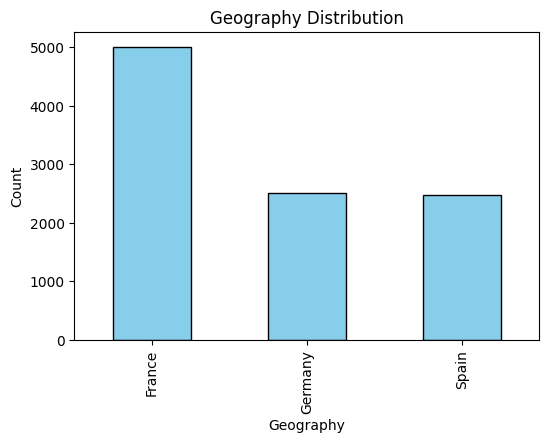

In [11]:
print("Unique values in Geography:", bank_data['Geography'].unique())

print("\nCounts for each category:")
print(bank_data['Geography'].value_counts())


plt.figure(figsize=(6,4))
bank_data['Geography'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Geography Distribution")
plt.xlabel("Geography")
plt.ylabel("Count")
plt.show()


Unique values in Gender: ['Female' 'Male']

Counts for each category:
Gender
Male      5457
Female    4543
Name: count, dtype: int64


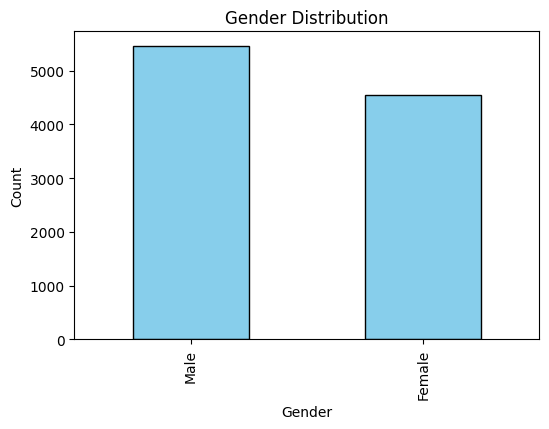

In [12]:
print("Unique values in Gender:", bank_data['Gender'].unique())

print("\nCounts for each category:")
print(bank_data['Gender'].value_counts())


plt.figure(figsize=(6,4))
bank_data['Gender'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()


Unique values in Exited: [1 0]

Counts for each category:
Exited
0    7963
1    2037
Name: count, dtype: int64


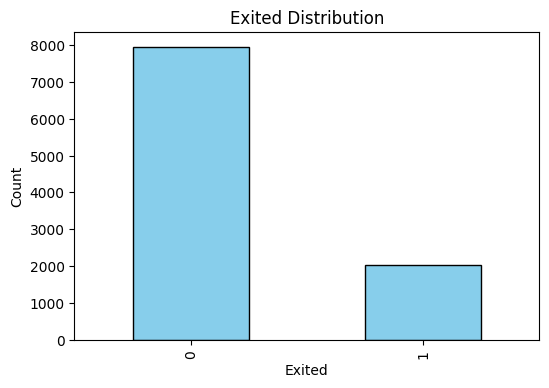

In [13]:
print("Unique values in Exited:", bank_data['Exited'].unique())

print("\nCounts for each category:")
print(bank_data['Exited'].value_counts())


plt.figure(figsize=(6,4))
bank_data['Exited'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Exited Distribution")
plt.xlabel("Exited")
plt.ylabel("Count")
plt.show()


<Axes: xlabel='EstimatedSalary'>

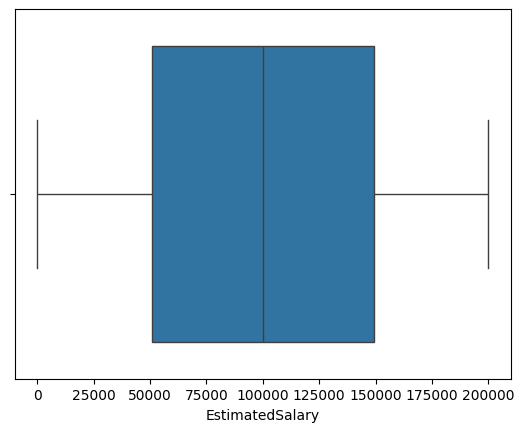

In [14]:
sns.boxplot(x=bank_data['EstimatedSalary'])

<Axes: xlabel='Balance'>

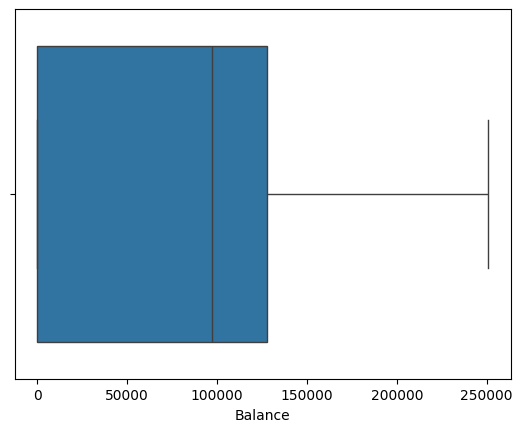

In [15]:
sns.boxplot(x=bank_data['Balance'])

<Axes: xlabel='CreditScore'>

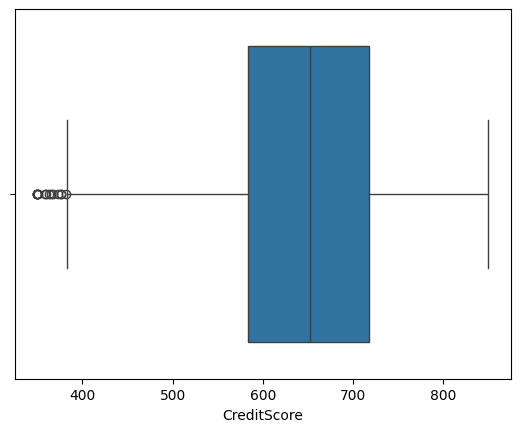

In [16]:
sns.boxplot(x=bank_data['CreditScore'])

<Axes: xlabel='Age'>

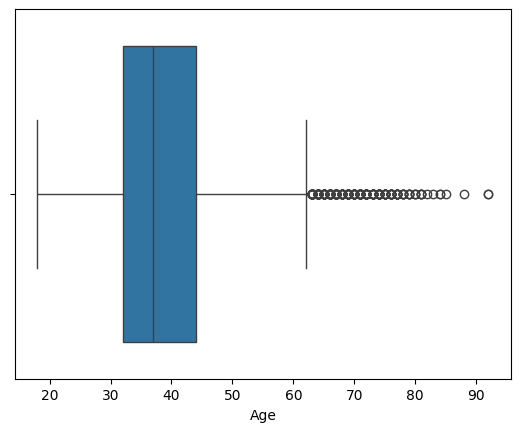

In [17]:
sns.boxplot(x=bank_data['Age'])

<Axes: xlabel='NumOfProducts'>

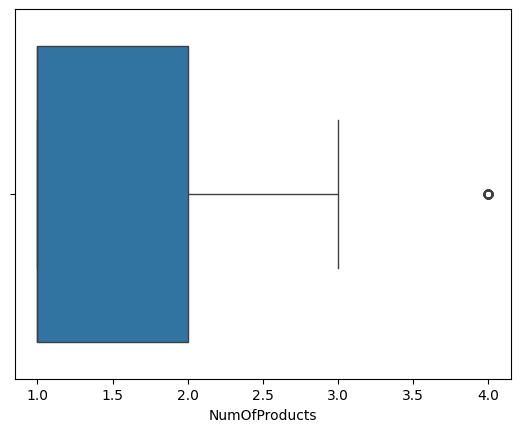

In [18]:
sns.boxplot(x=bank_data['NumOfProducts'])

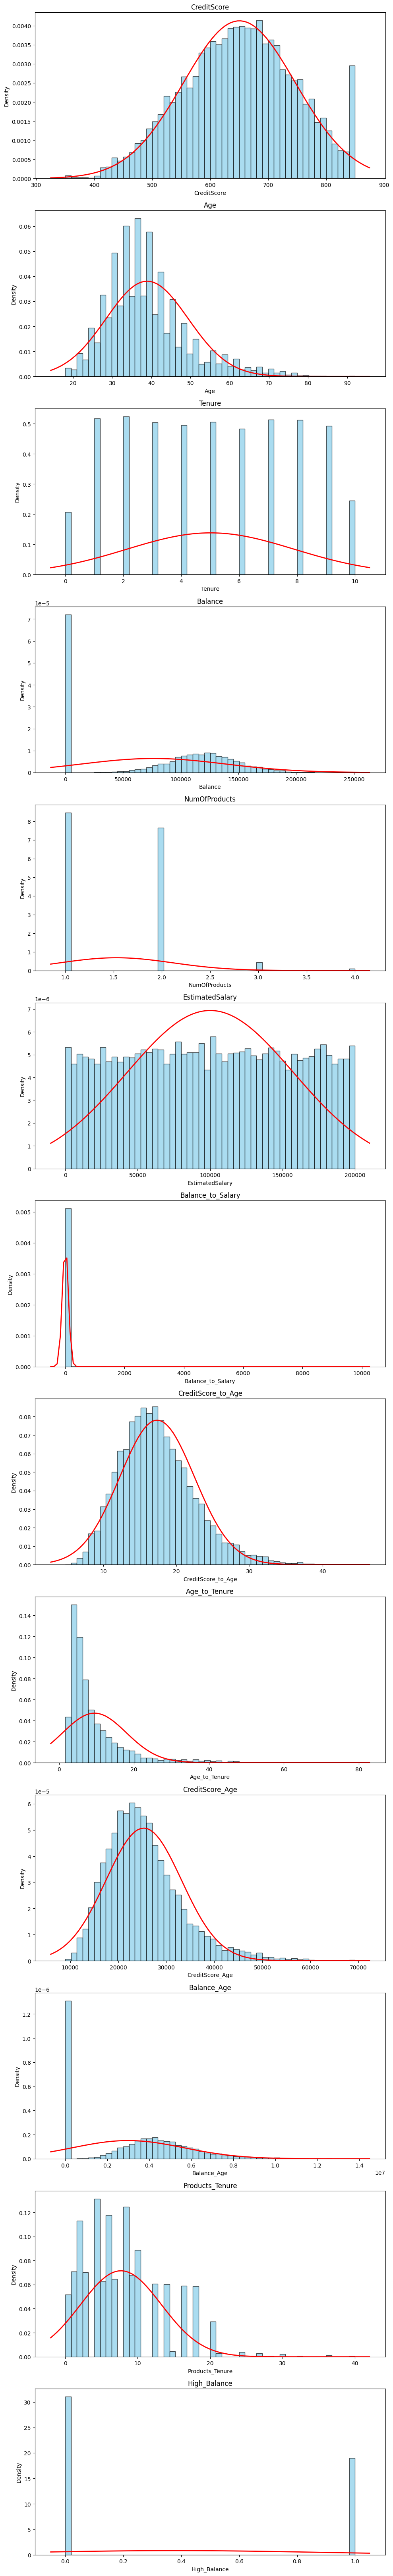

In [19]:

numeric_cols = bank_data.select_dtypes(include=[np.number]).columns


exclude_cols = ["HasCrCard", "Exited","IsActiveMember"]


cols_to_plot = [col for col in numeric_cols if col not in exclude_cols]


fig, axes = plt.subplots(len(cols_to_plot), 1, figsize=(10, 5*len(cols_to_plot)))

for i, col in enumerate(cols_to_plot):
    data = bank_data[col].dropna()
    mu, sigma = data.mean(), data.std()

   
    axes[i].hist(data, bins=50, density=True, color='skyblue', alpha=0.7, edgecolor='black')

   
    xmin, xmax = axes[i].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, sigma)
    axes[i].plot(x, p, 'r', linewidth=2)

    axes[i].set_title( col )
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Density")

plt.tight_layout()
plt.show()


In [20]:
bank_data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Balance_to_Salary,CreditScore_to_Age,Age_to_Tenure,CreditScore_Age,Balance_Age,Products_Tenure,High_Balance
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.000000,14.395349,14.000000,25998,0.00,2,0
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.744670,14.476190,20.500000,24928,3436122.26,1,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1.401362,11.674419,4.666667,21084,6705753.60,24,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.000000,17.475000,19.500000,27261,0.00,2,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1.587035,19.318182,14.333333,36550,5396965.26,2,1


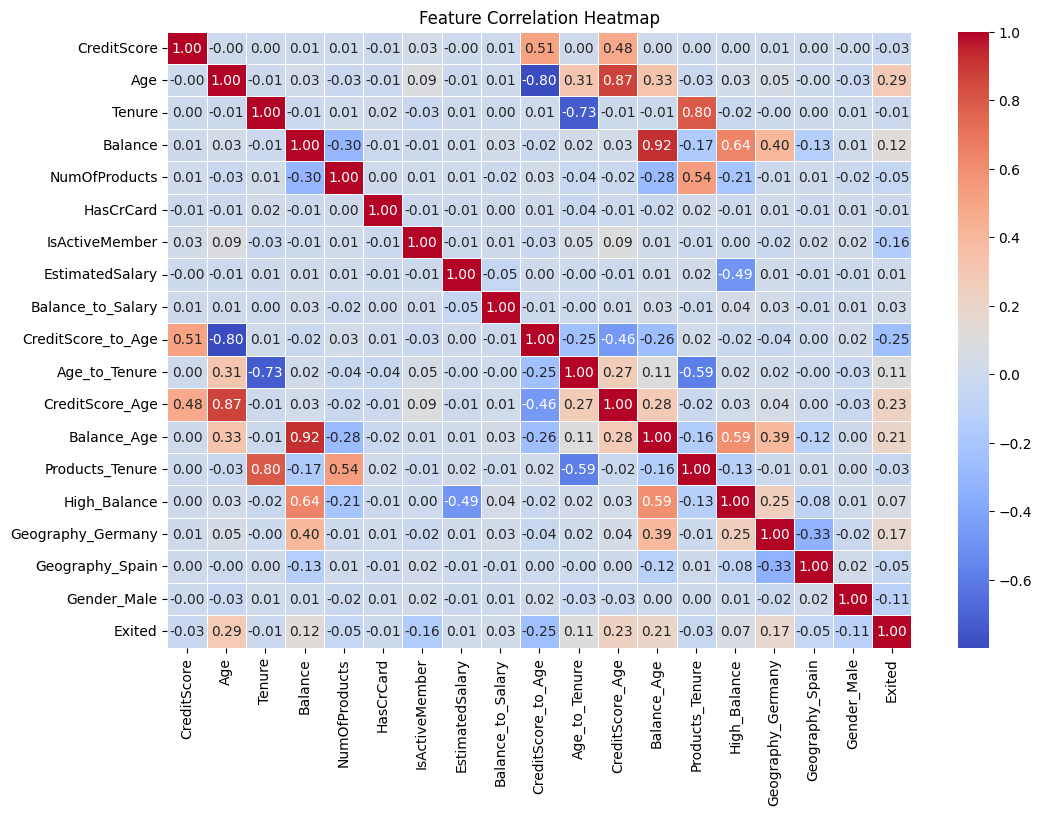

In [35]:
correlation_matrix = bank_data.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

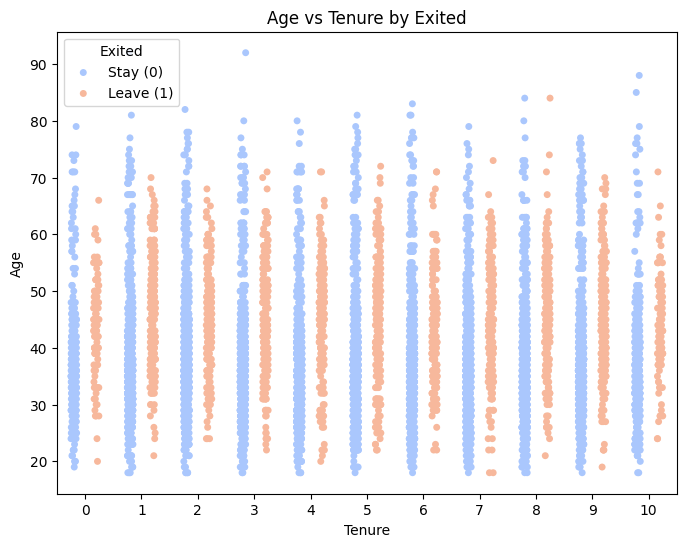

In [ ]:
plt.figure(figsize=(8,6))
sns.stripplot(x="Tenure", y="Age", hue="Exited", data=bank_data, jitter=True, dodge=True, palette="coolwarm")
plt.title("Age vs Tenure by Exited")
plt.xlabel("Tenure")
plt.ylabel("Age")
plt.legend(title="Exited", labels=["Stay (0)", "Leave (1)"])
plt.show()


In [38]:
bank_data = bank_data[bank_data['Age'] >= bank_data['Tenure'] + 18]

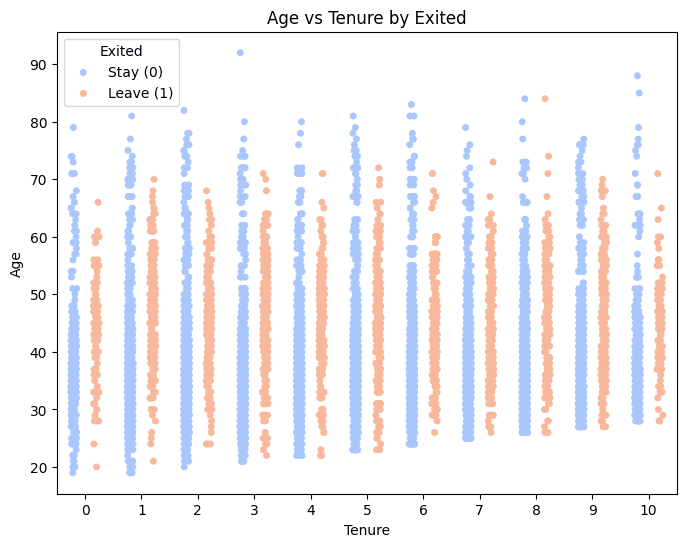

In [39]:
plt.figure(figsize=(8,6))
sns.stripplot(x="Tenure", y="Age", hue="Exited", data=bank_data, jitter=True, dodge=True, palette="coolwarm")
plt.title("Age vs Tenure by Exited")
plt.xlabel("Tenure")
plt.ylabel("Age")
plt.legend(title="Exited", labels=["Stay (0)", "Leave (1)"])
plt.show()


## 🔤 Encoding Categorical Features

Machine learning models require numeric inputs, so the categorical columns `Gender` and `Geography` are transformed using **One-Hot Encoding**.

- A binary column is created for each category (e.g., `Geography_France`, `Geography_Germany`, `Geography_Spain`).
- `drop_first=True` is applied to avoid the **dummy variable trap** (multicollinearity), dropping one reference category per variable.

> **Outcome:** categorical data becomes machine-readable while preserving all relevant geographic and demographic information.

In [22]:
categorical_cols = ['Geography', 'Gender']

bank_data = pd.get_dummies(bank_data, columns=categorical_cols, drop_first=True, dtype = int)

bank_data.head()


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Balance_to_Salary,CreditScore_to_Age,Age_to_Tenure,CreditScore_Age,Balance_Age,Products_Tenure,High_Balance,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0.000000,14.395349,14.000000,25998,0.00,2,0,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0.744670,14.476190,20.500000,24928,3436122.26,1,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,1.401362,11.674419,4.666667,21084,6705753.60,24,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0.000000,17.475000,19.500000,27261,0.00,2,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1.587035,19.318182,14.333333,36550,5396965.26,2,1,0,1,0


In [23]:
exited_col = bank_data.pop('Exited')


bank_data['Exited'] = exited_col


bank_data.head()


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Balance_to_Salary,CreditScore_to_Age,Age_to_Tenure,CreditScore_Age,Balance_Age,Products_Tenure,High_Balance,Geography_Germany,Geography_Spain,Gender_Male,Exited
0,619,42,2,0.00,1,1,1,101348.88,0.000000,14.395349,14.000000,25998,0.00,2,0,0,0,0,1
1,608,41,1,83807.86,1,0,1,112542.58,0.744670,14.476190,20.500000,24928,3436122.26,1,0,0,1,0,0
2,502,42,8,159660.80,3,1,0,113931.57,1.401362,11.674419,4.666667,21084,6705753.60,24,1,0,0,0,1
3,699,39,1,0.00,2,0,0,93826.63,0.000000,17.475000,19.500000,27261,0.00,2,0,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,1.587035,19.318182,14.333333,36550,5396965.26,2,1,0,1,0,0


## ✂️ Train-Test Split

The dataset is divided into a **training set** (80%) and a **testing set** (20%) to enable unbiased model evaluation.

- **Stratified split** (`stratify=y`) is used to preserve the class distribution across both sets — essential when dealing with imbalanced targets.
- The training set is used to fit the model; the test set simulates performance on unseen data.

In [24]:
X = bank_data.drop('Exited', axis=1)
y = bank_data['Exited']

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [25]:
X_train.shape

(8000, 18)

In [26]:
y_train.shape

(8000,)

## ⚖️ Handling Class Imbalance: SMOTETomek

The target variable is imbalanced — churned customers are a minority. To address this, **SMOTETomek** is applied exclusively to the training data:

- **SMOTE** generates synthetic samples for the minority (churned) class.
- **Tomek Links** removes borderline ambiguous samples near the decision boundary.

Together, they produce a **cleaner and more balanced training set**, improving recall and F1-score for the churn class without leaking information into the test set.

In [27]:
print(X_train.dtypes)
print(X_train.head())


CreditScore             int64
Age                     int64
Tenure                  int64
Balance               float64
NumOfProducts           int64
HasCrCard               int64
IsActiveMember          int64
EstimatedSalary       float64
Balance_to_Salary     float64
CreditScore_to_Age    float64
Age_to_Tenure         float64
CreditScore_Age         int64
Balance_Age           float64
Products_Tenure         int64
High_Balance            int32
Geography_Germany       int32
Geography_Spain         int32
Gender_Male             int32
dtype: object
      CreditScore  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
9254          686   32       6       0.00              2          1   
1561          632   42       4  119624.60              2          1   
1670          559   24       3  114739.92              1          1   
6087          561   27       9  135637.00              1          1   
6669          517   56       9  142147.32              1          0   

      IsActiveMembe

In [28]:

smt = SMOTETomek(random_state=42)
X_res_smt, y_res_smt = smt.fit_resample(X_train, y_train)

print("SMOTETomek:")
print(y_res_smt.value_counts())


SMOTETomek:
Exited
0    5828
1    5828
Name: count, dtype: int64


## 🤖 Model Building & Comparison

Three tree-based ensemble models are trained and compared using **5-fold cross-validated GridSearchCV**:

| Model | Key Strength | Key Weakness |
|---|---|---|
| **Random Forest** | Robust, easy to interpret feature importance | Can be slower; less sharp on highly imbalanced data |
| **LightGBM** | Very fast; low memory; excellent on large datasets | May overfit small datasets without careful tuning |
| **XGBoost** | Strong generalization with built-in regularization | Slower than LightGBM on large datasets; more hyperparameters |

All models are evaluated on the **held-out test set** using accuracy, classification report, and ROC-AUC curves. The best-performing configuration is then retrained and saved for deployment.

In [29]:
models_params = {
    "Random Forest": (
        RandomForestClassifier(random_state=42, class_weight="balanced"),
        {'n_estimators': [100, 200, 300], 'max_depth': [3, 5, 10, 15], 'min_samples_split': [2, 5, 15]}
    ),
    "XGBoost": (
        XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, scale_pos_weight=4),
        {'n_estimators': [100, 200, 300], 'max_depth': [3, 5, 10, 15], 'learning_rate': [0.05, 0.1, 0.01]}
    ),
    "LightGBM": (
        LGBMClassifier(random_state=42, class_weight="balanced"),
        {'n_estimators': [100, 200, 300], 'max_depth': [3, 5, 10], 'learning_rate': [0.05, 0.1, 0.01]}
    )
}


In [30]:
results = []

for name, (model, params) in models_params.items():
    print(f"\n--- Training {name} ---")
    grid = GridSearchCV(model, params, cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_res_smt, y_res_smt)
    
    print(f"{name} Best Params: {grid.best_params_}")
    print(f"{name} CV Best Score: {grid.best_score_:.4f}")
    
    y_pred = grid.best_estimator_.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Test Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))
    
    if hasattr(grid.best_estimator_, "predict_proba"):  
        y_prob = grid.best_estimator_.predict_proba(X_test)[:,1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        results.append((fpr, tpr, roc_auc, name))


--- Training Random Forest ---
Random Forest Best Params: {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 300}
Random Forest CV Best Score: 0.8597
Random Forest Test Accuracy: 0.8315
              precision    recall  f1-score   support

           0       0.91      0.87      0.89      1607
           1       0.56      0.67      0.61       393

    accuracy                           0.83      2000
   macro avg       0.74      0.77      0.75      2000
weighted avg       0.84      0.83      0.84      2000


--- Training XGBoost ---
XGBoost Best Params: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 300}
XGBoost CV Best Score: 0.8742
XGBoost Test Accuracy: 0.8155
              precision    recall  f1-score   support

           0       0.91      0.85      0.88      1607
           1       0.52      0.67      0.59       393

    accuracy                           0.82      2000
   macro avg       0.72      0.76      0.73      2000
weighted avg       0.84      0.82      

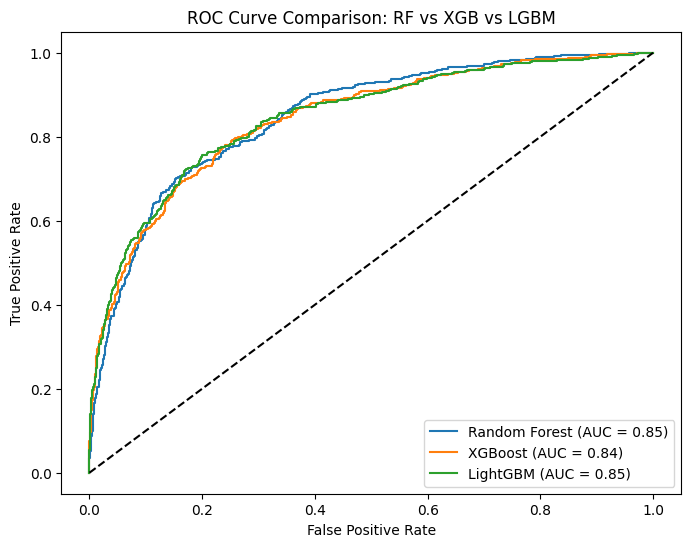

In [31]:
plt.figure(figsize=(8,6))
for fpr, tpr, roc_auc, name in results:
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: RF vs XGB vs LGBM")
plt.legend()
plt.show()

## 💾 Final Model: Random Forest

Based on the GridSearchCV results, the **Random Forest** with the best hyperparameters is retrained on the full resampled training set and saved to disk using `joblib` for later deployment or inference.

In [34]:

rf_model = RandomForestClassifier(
    n_estimators=200, 
    max_depth=15, 
    min_samples_split=2, 
    random_state=42,
    class_weight="balanced"
)


rf_model.fit(X_res_smt, y_res_smt)

y_pred = rf_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


joblib.dump(rf_model, "random_forest_model.joblib")
print("✅ Model saved as random_forest_model.joblib")


Accuracy: 0.828
✅ Model saved as random_forest_model.joblib
